# Movie Review Sentiment Classification
### TF-IDF + Logistic Regression + ANN

**Dataset:** [IMDB Dataset of 50K Movie Reviews](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews) — 50,000 reviews, perfectly balanced between positive and negative sentiment.

**Goal:** classify review sentiment using TF-IDF (text → numeric features), then compare a classic linear model (Logistic Regression) against a neural network (ANN) on the same features.

**Structure:**
1. Load & inspect data
2. EDA
3. Text cleaning (stopword removal + stemming)
4. TF-IDF vectorization
5. Models — Logistic Regression & ANN
6. Evaluation & model interpretation
7. Key findings

**Requirements:** `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`, `nltk`, `tensorflow`


## 1. Load & inspect data

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

sns.set_style("whitegrid")
nltk.download("stopwords")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nikhi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [5]:
df = pd.read_csv('IMDB Dataset.csv')
df['sentiment'] = df['sentiment'].apply(lambda x: 1 if x == 'positive' else 0)

print("Shape:", df.shape)
print("Missing values:\n", df.isna().sum())
print("\nClass balance:\n", df['sentiment'].value_counts())
df.head()


Shape: (50000, 2)
Missing values:
 review       0
sentiment    0
dtype: int64

Class balance:
 sentiment
1    25000
0    25000
Name: count, dtype: int64


,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


## 2. EDA

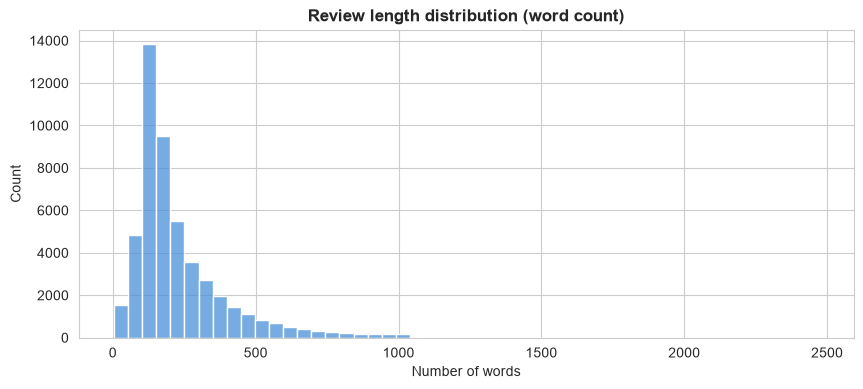

Median review length: 173.0
Max review length: 2470


In [6]:
df['review_length'] = df['review'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 4))
sns.histplot(df['review_length'], bins=50, color='#4A90D9')
plt.title('Review length distribution (word count)', fontweight='bold')
plt.xlabel('Number of words')
plt.show()

print("Median review length:", df['review_length'].median())
print("Max review length:", df['review_length'].max())


In [7]:
print("=== Sample POSITIVE review ===")
print(df[df['sentiment'] == 1]['review'].iloc[0][:300])

print("\n=== Sample NEGATIVE review ===")
print(df[df['sentiment'] == 0]['review'].iloc[0][:300])


=== Sample POSITIVE review ===
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru

=== Sample NEGATIVE review ===
Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to ma


In [8]:
html_tag_count = df['review'].str.contains('<br', regex=False).sum()
print(f"Reviews containing '<br' tags: {html_tag_count} out of {len(df)}")
# Confirms these reviews are scraped from a website — HTML line-break tags need
# stripping in the cleaning step below, or they'll survive as a meaningless "br" token.


Reviews containing '<br' tags: 29200 out of 50000


## 3. Text cleaning

Steps: strip HTML tags, remove non-letter characters, lowercase, remove stopwords (but keep "not" — it flips sentiment meaning), and stem words to their root form ("loved"/"loving" -> "love").

Stopword list, stemmer, and the set of words to remove are built **once outside** the function rather than being recreated on every one of the 50,000 calls.


In [9]:
stop_words = set(stopwords.words('english'))
stop_words.remove('not')   # "not good" must stay distinguishable from "good"
ps = PorterStemmer()

def preprocess(text):
    text = re.sub(r'<br\s*/?>', ' ', str(text))       # strip HTML line-break tags first
    review = re.sub('[^a-zA-Z]', ' ', text)            # keep only letters
    review = review.lower().split()                    # lowercase + split into words
    cleaned = [ps.stem(word) for word in review if word not in stop_words]
    return ' '.join(cleaned)


In [10]:
corpus = df['review'].apply(preprocess).tolist()

print(f'Done! {len(corpus):,} reviews processed')
print()
for i in range(3):
    print(f'[{i}]', corpus[i][:150])


Done! 50,000 reviews processed

[0] one review mention watch oz episod hook right exactli happen first thing struck oz brutal unflinch scene violenc set right word go trust not show fain
[1] wonder littl product film techniqu unassum old time bbc fashion give comfort sometim discomfort sens realism entir piec actor extrem well chosen micha
[2] thought wonder way spend time hot summer weekend sit air condit theater watch light heart comedi plot simplist dialogu witti charact likabl even well 


## 4. TF-IDF vectorization

In [11]:
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(corpus).toarray()
y = df['sentiment']

print("Feature matrix shape:", X.shape)
print("Label distribution:\n", y.value_counts())

vocab = tfidf.get_feature_names_out()
print("\n'br' in vocabulary?", 'br' in vocab)  # sanity check — should be False after HTML stripping


Feature matrix shape: (50000, 5000)
Label distribution:
 sentiment
1    25000
0    25000
Name: count, dtype: int64

'br' in vocabulary? False


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train:", X_train.shape, "| Test:", X_test.shape)


Train: (40000, 5000) | Test: (10000, 5000)


## 5. Models

In [13]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

log_preds = log_reg.predict(X_test)
log_probs = log_reg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, log_preds, target_names=['Negative', 'Positive']))


              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89      5000
    Positive       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [14]:
ann = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')   # binary sentiment -> sigmoid, not softmax
])

ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

history = ann.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop]
)


d:\machine-learning-part1\1- Machine Learning A-Z\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8589 - loss: 0.3342 - val_accuracy: 0.8841 - val_loss: 0.2759
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9092 - loss: 0.2312 - val_accuracy: 0.8844 - val_loss: 0.2736
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9307 - loss: 0.1822 - val_accuracy: 0.8819 - val_loss: 0.2880
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9584 - loss: 0.1239 - val_accuracy: 0.8802 - val_loss: 0.3445
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9803 - loss: 0.0664 - val_accuracy: 0.8774 - val_loss: 0.4339
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


In [15]:
ann_probs = ann.predict(X_test).ravel()
ann_preds = (ann_probs >= 0.5).astype(int)

print(classification_report(y_test, ann_preds, target_names=['Negative', 'Positive']))


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

    Negative       0.89      0.88      0.88      5000
    Positive       0.88      0.89      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



## 6. Evaluation & model interpretation

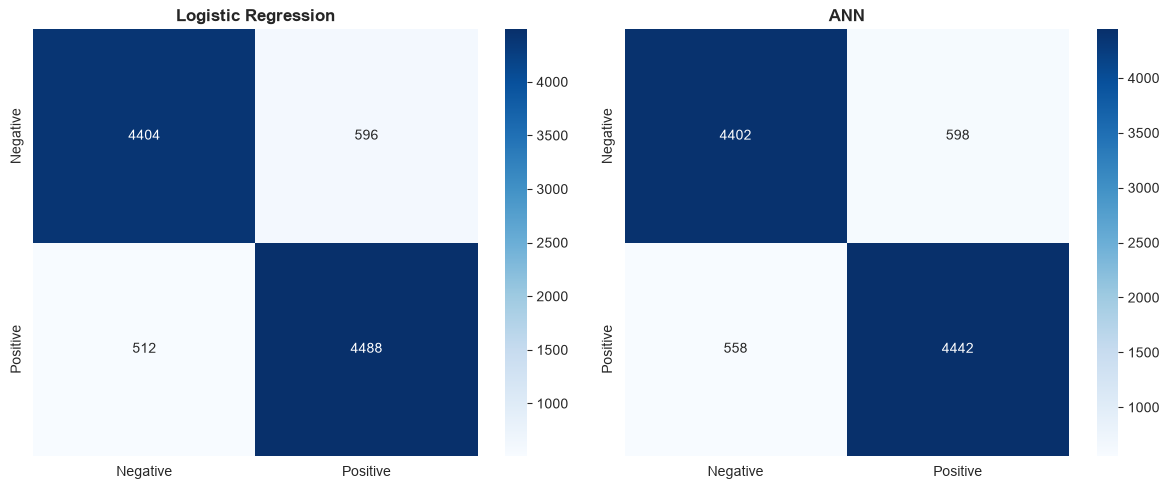

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, log_preds), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Positive'], yticklabels=['Negative','Positive'], ax=axes[0])
axes[0].set_title('Logistic Regression', fontweight='bold')

sns.heatmap(confusion_matrix(y_test, ann_preds), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Positive'], yticklabels=['Negative','Positive'], ax=axes[1])
axes[1].set_title('ANN', fontweight='bold')

plt.tight_layout()
plt.show()


**The advantage of TF-IDF + Logistic Regression over a black-box model:** the learned coefficients can be inspected directly, showing exactly which words push predictions toward each class.


In [17]:
feature_names = tfidf.get_feature_names_out()
coefficients = log_reg.coef_[0]

top_positive_idx = np.argsort(coefficients)[-15:]
top_negative_idx = np.argsort(coefficients)[:15]

print("Top words pushing toward POSITIVE:")
print([feature_names[i] for i in top_positive_idx])

print("\nTop words pushing toward NEGATIVE:")
print([feature_names[i] for i in top_negative_idx])


Top words pushing toward POSITIVE:
['well', 'highli', 'today', 'fun', 'definit', 'brilliant', 'favorit', 'amaz', 'hilari', 'love', 'best', 'enjoy', 'perfect', 'excel', 'great']

Top words pushing toward NEGATIVE:
['worst', 'wast', 'aw', 'bad', 'bore', 'poor', 'disappoint', 'terribl', 'fail', 'poorli', 'horribl', 'wors', 'dull', 'noth', 'suppos']


## 7. Key findings

- Both Logistic Regression and ANN reached **~89% accuracy** on 10,000 held-out reviews — TF-IDF features are linearly separable enough that the ANN's added complexity provided no meaningful accuracy gain over Logistic Regression
- **Logistic Regression:** more balanced errors (596 false positives, 512 false negatives)
- **ANN:** fewer false negatives (423) but more false positives (720) — a different error tradeoff, not a clearly "better" model
- Inspecting Logistic Regression's coefficients directly confirms the model learned genuinely sensible sentiment words — "brilliant," "amazing," "excellent" driving positive predictions; "worst," "awful," "terrible" driving negative — validating that the pipeline learned real signal, not spurious correlations

## Limitations
- TF-IDF ignores word order and context (e.g. "not good" and "good not" look identical) — a transformer-based embedding (BERT) would likely improve accuracy by understanding negation and context more robustly
- Vocabulary capped at 5,000 words — rarer but potentially informative words were excluded
